In [25]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd


In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Normalization

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [56]:
#datadset
from sklearn.datasets import load_wine
import numpy as np

data = load_wine(as_frame=False) 
X = data.data  
Y_multi = data.target  

Y = (Y_multi == 0).astype(int).reshape(-1, 1)

from sklearn.model_selection import train_test_split


X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.176, random_state=42)


In [57]:


print(data.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [58]:
print(data.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [59]:
print(data.target_names)

['class_0' 'class_1' 'class_2']


In [60]:
df=data
# type(df)

In [61]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = Y_multi

<Figure size 1200x1000 with 0 Axes>

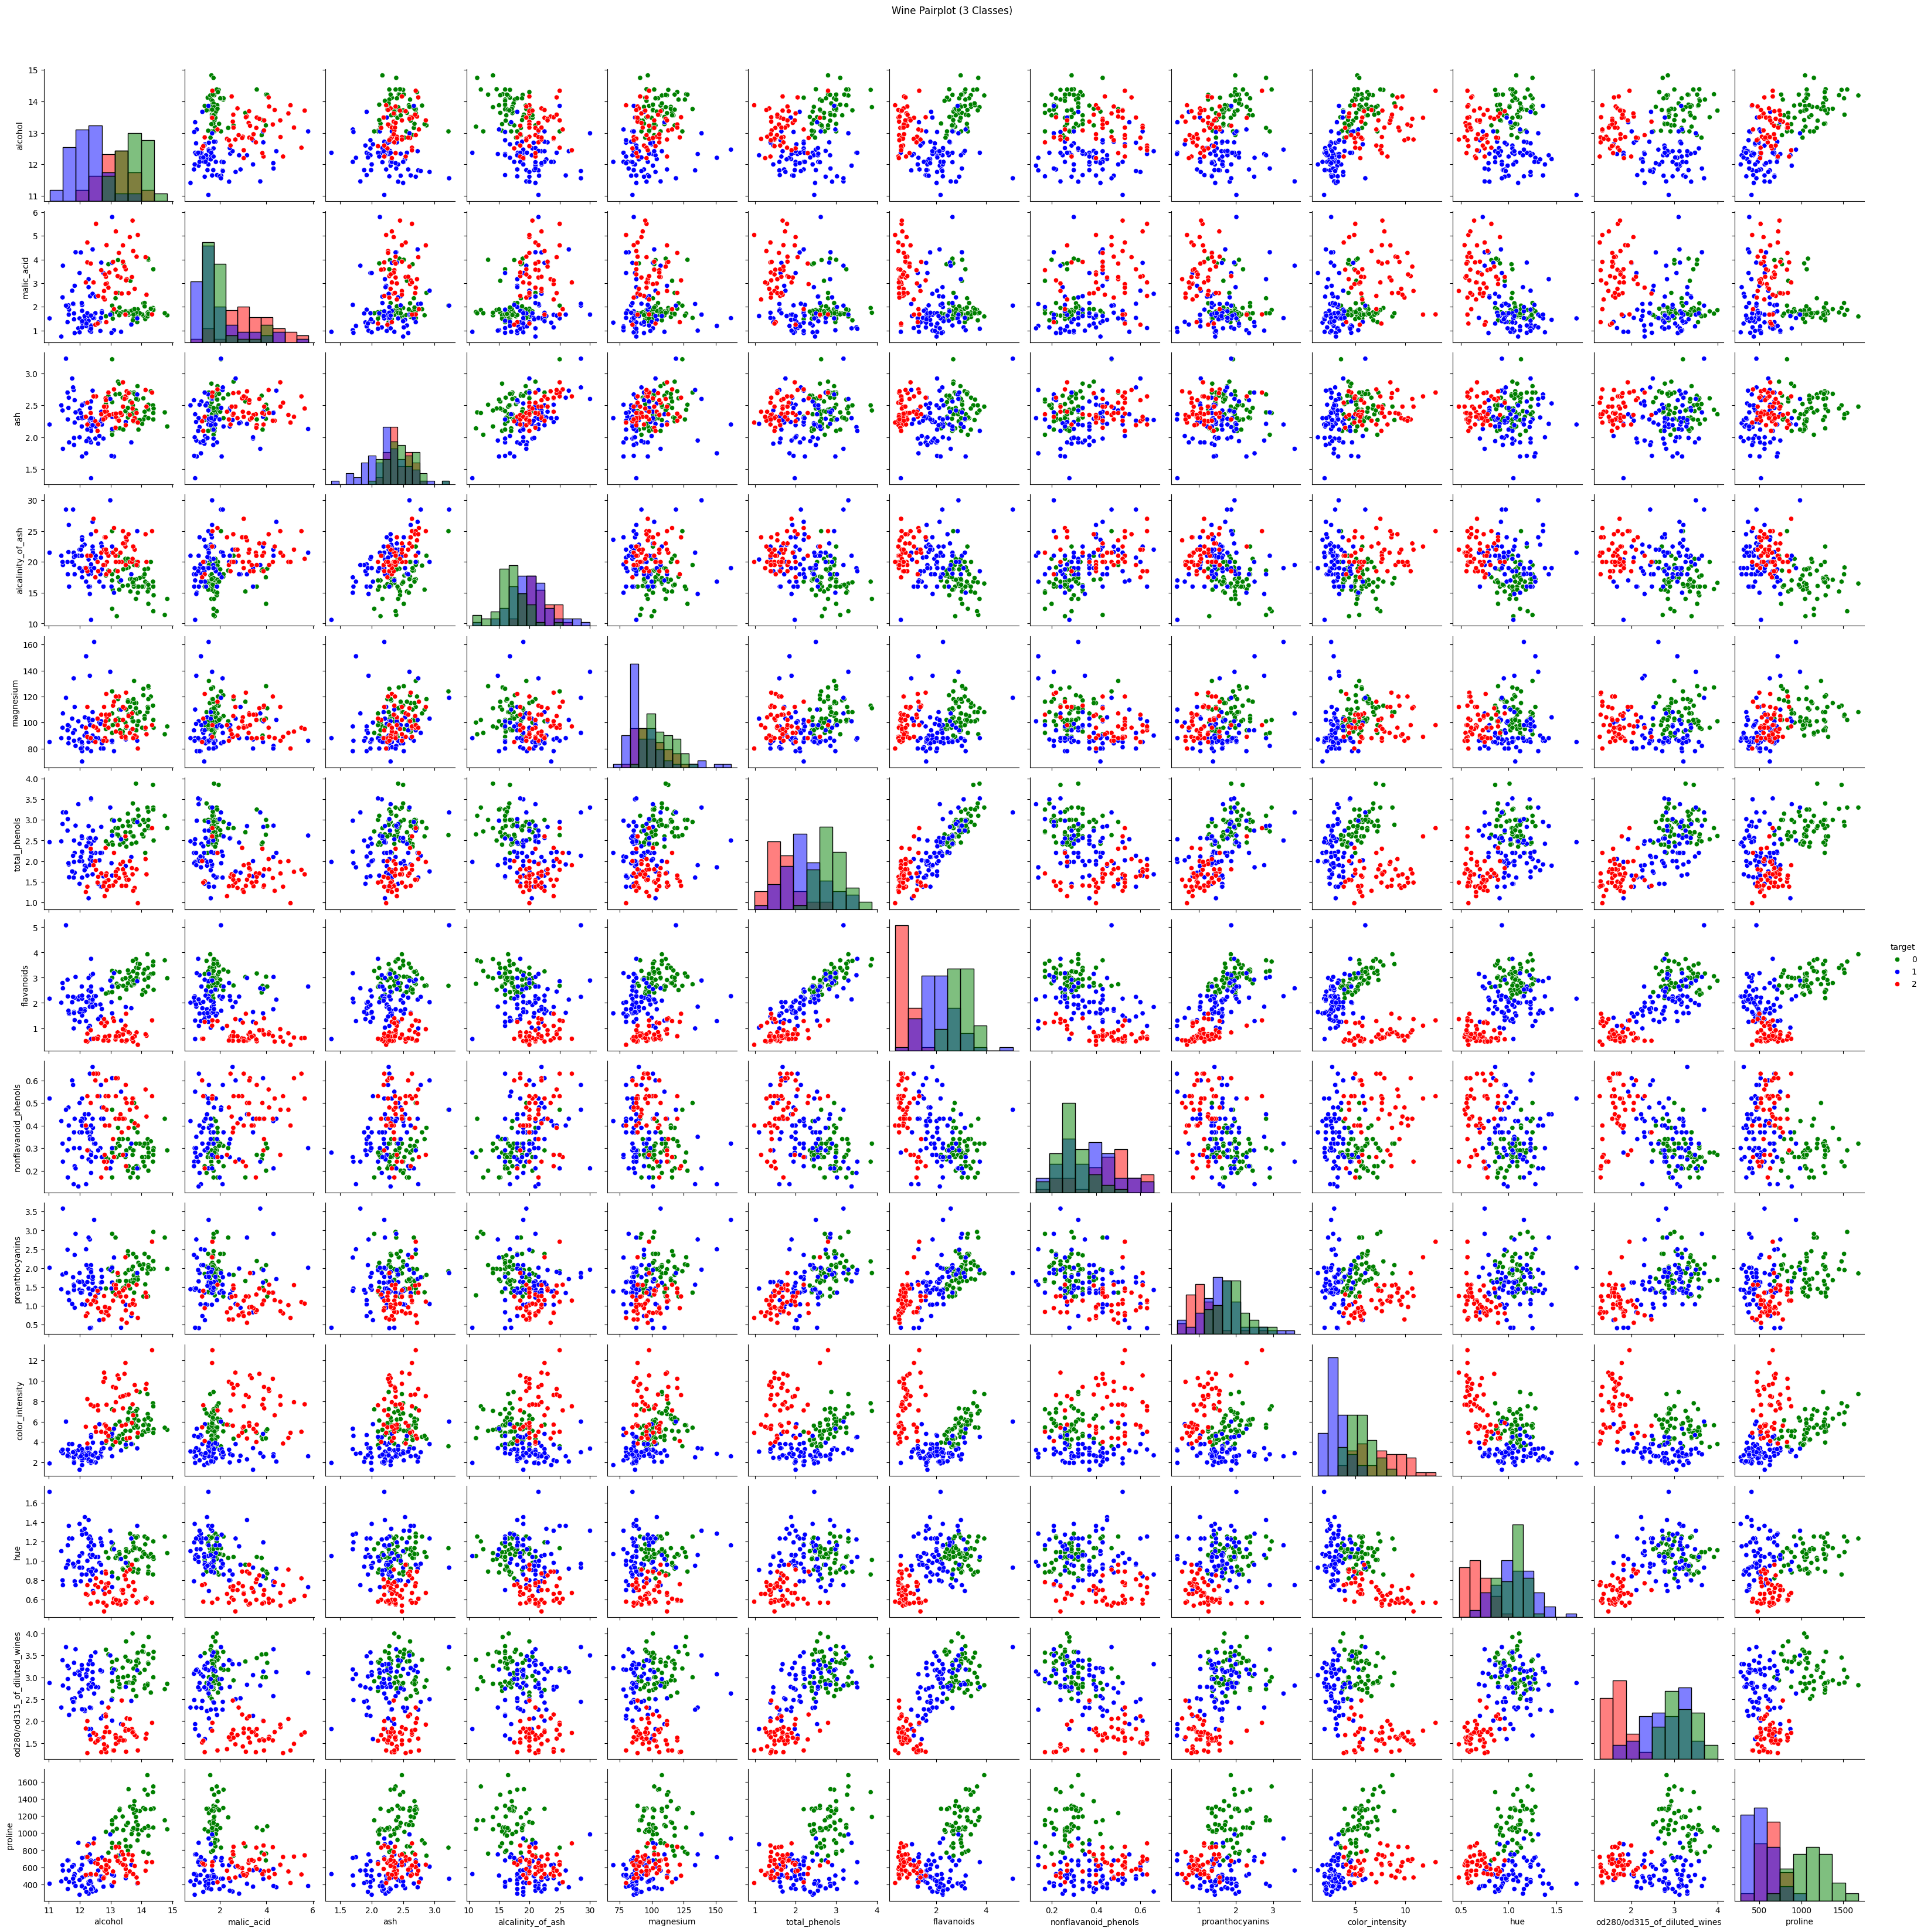

In [62]:
colors = ['green', 'blue', 'red']
class_names = ['Class 0', 'Class 1', 'Class 2']

# 1. Pairplot with explicit palette
palette_dict = dict(zip([0,1,2], colors))
plt.figure(figsize=(12,10))
sns.pairplot(df, hue='target', palette=palette_dict, diag_kind='hist')
plt.suptitle('Wine Pairplot (3 Classes)', y=1.02)
plt.show()

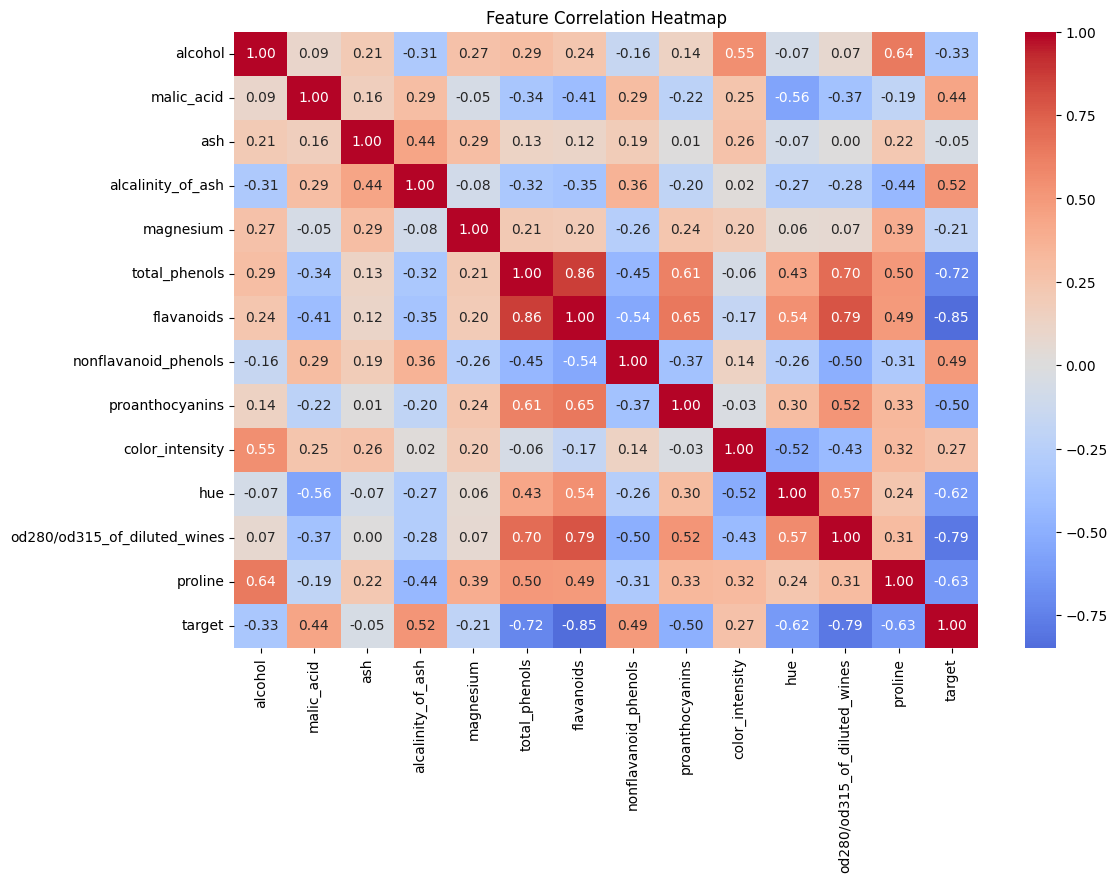

In [63]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

/var/folders/yp/wjhk065x3bsb2sh5cfpt6gd40000gn/T/ipykernel_54493/2053382414.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target', y=feat, ax=axes[i], palette='husl')
/var/folders/yp/wjhk065x3bsb2sh5cfpt6gd40000gn/T/ipykernel_54493/2053382414.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target', y=feat, ax=axes[i], palette='husl')
/var/folders/yp/wjhk065x3bsb2sh5cfpt6gd40000gn/T/ipykernel_54493/2053382414.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target', y=feat, ax=axes[i],

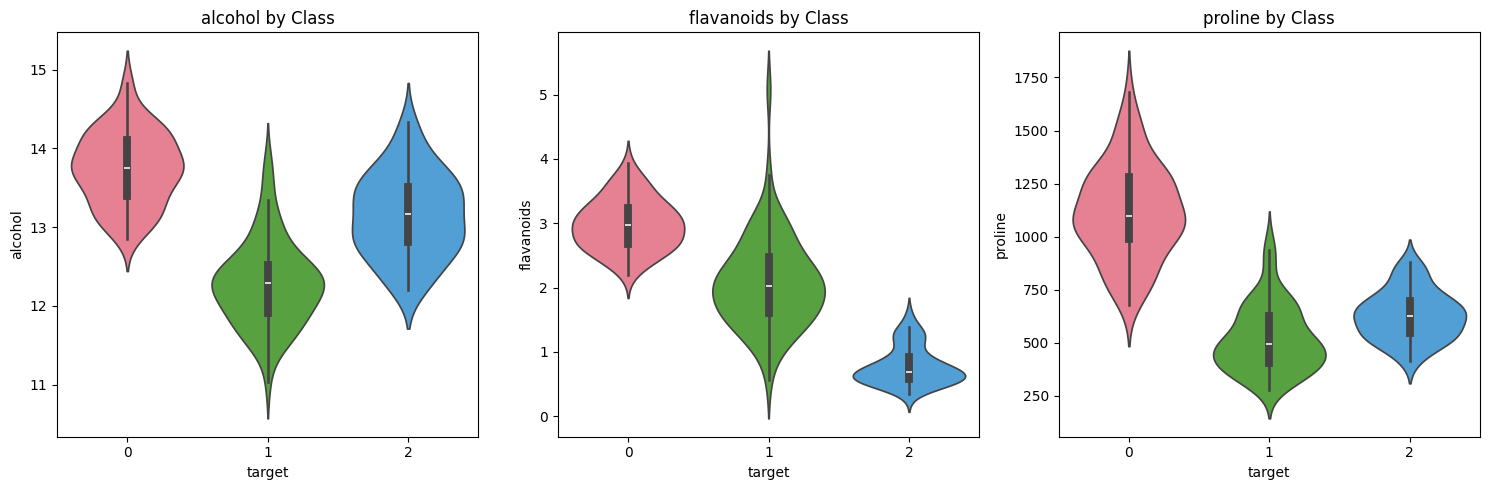

In [64]:
key_feats = ['alcohol', 'flavanoids', 'proline']
fig, axes = plt.subplots(1,3, figsize=(15,5))
for i, feat in enumerate(key_feats):
    sns.violinplot(data=df, x='target', y=feat, ax=axes[i], palette='husl')
    axes[i].set_title(f'{feat} by Class')
plt.tight_layout(); plt.show()

/var/folders/yp/wjhk065x3bsb2sh5cfpt6gd40000gn/T/ipykernel_54493/1646468266.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='flavanoids', palette='husl')


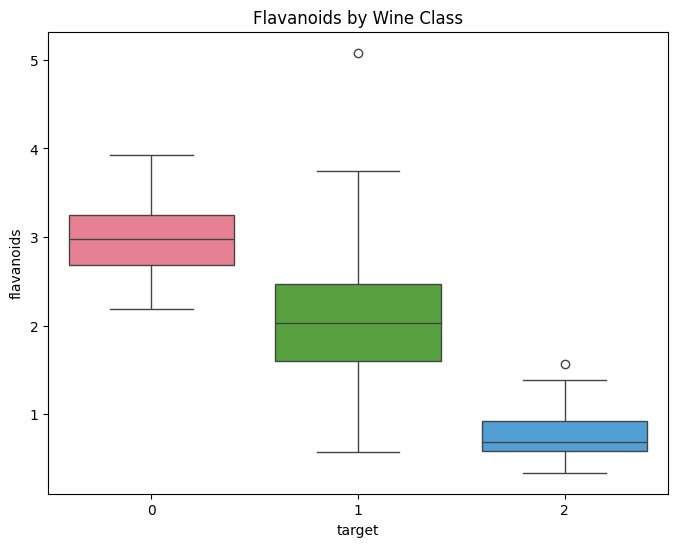

In [65]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='target', y='flavanoids', palette='husl')
plt.title('Flavanoids by Wine Class')
plt.show()

In [66]:
norm_layer = Normalization()
norm_layer.adapt(X_train)
Xt_train, Xt_val, Xt_test = norm_layer(X_train), norm_layer(X_val), norm_layer(X_test)

In [72]:
print("Shapes:", Xt_train.shape, Xt_val.shape, Xt_test.shape)

Shapes: (124, 13) (27, 13) (27, 13)


In [54]:
print(data.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [75]:
tf.random.set_seed(1234)  
model = Sequential(
    [
        tf.keras.Input(shape=(13,)),
        Dense(3, activation='sigmoid', name = 'layer1'),
        Dense(1, activation='sigmoid', name = 'layer2')
     ]
)

In [76]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46 (184.00 B)

 Trainable params: 46 (184.00 B)

 Non-trainable params: 0 (0.00 B)

In [77]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
)

In [79]:
model.fit(
    Xt_train,Y_train,      
    epochs=10,
    validation_data=(Xt_val, Y_val),      
    verbose=1,
    batch_size=16 
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7494 - val_loss: 0.6609
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6398 - val_loss: 0.5592
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5208 - val_loss: 0.4793
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4401 - val_loss: 0.4294
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3916 - val_loss: 0.3997
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3590 - val_loss: 0.3802
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3337 - val_loss: 0.3656
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3121 - val_loss: 0.3533
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2929 - val_loss: 0.3422
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2751 - val_loss: 0.3315


In [80]:
predictions = model.predict(Xt_test)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
predictions = 
 [[0.43828136]
 [0.7072753 ]
 [0.36882356]
 [0.7072753 ]
 [0.36882365]
 [0.7072753 ]
 [0.3688236 ]
 [0.3688286 ]
 [0.36888275]
 [0.6353427 ]
 [0.7042924 ]
 [0.36882356]
 [0.7072753 ]
 [0.36882356]
 [0.7072753 ]
 [0.36882356]
 [0.36882356]
 [0.36884552]
 [0.7072753 ]
 [0.36882356]
 [0.7072753 ]
 [0.36884892]
 [0.36883107]
 [0.36882356]
 [0.36882353]
 [0.36882368]
 [0.36882353]]


In [81]:
y_pred_prob = model.predict(Xt_test)

# Convert to binary predictions (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [82]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(Y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Detailed metrics
print(classification_report(Y_test, y_pred))

Test Accuracy: 0.8889
Test Accuracy: 88.89%
              precision    recall  f1-score   support

           0       0.94      0.89      0.91        18
           1       0.80      0.89      0.84         9

    accuracy                           0.89        27
   macro avg       0.87      0.89      0.88        27
weighted avg       0.89      0.89      0.89        27



In [83]:
#the visualtizations below are ai getenrated

## Neural Network Visualization

Let's examine what each hidden unit learned and visualize the network's decision boundary using the two most important features.

In [84]:
# Extract weights from each layer
W1, b1 = model.get_layer('layer1').get_weights()
W2, b2 = model.get_layer('layer2').get_weights()

print(f"Layer 1 weights shape: {W1.shape}")  # (13, 3)
print(f"Layer 1 bias shape: {b1.shape}")      # (3,)
print(f"Layer 2 weights shape: {W2.shape}")  # (3, 1)
print(f"Layer 2 bias shape: {b2.shape}")      # (1,)

Layer 1 weights shape: (13, 3)
Layer 1 bias shape: (3,)
Layer 2 weights shape: (3, 1)
Layer 2 bias shape: (1,)


In [85]:
# Use the two most important features: flavanoids (index 6) and alcohol (index 0)
feat_idx1, feat_idx2 = 6, 0  # flavanoids and alcohol

# Create a grid of values for these two features
x1_range = np.linspace(Xt_train[:, feat_idx1].numpy().min(), Xt_train[:, feat_idx1].numpy().max(), 100)
x2_range = np.linspace(Xt_train[:, feat_idx2].numpy().min(), Xt_train[:, feat_idx2].numpy().max(), 100)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# Create input array with mean values for other features
X_grid = np.zeros((100*100, 13))
X_grid[:, feat_idx1] = X1_grid.ravel()
X_grid[:, feat_idx2] = X2_grid.ravel()

# Fill other features with their mean values
for i in range(13):
    if i not in [feat_idx1, feat_idx2]:
        X_grid[:, i] = Xt_train[:, i].numpy().mean()

print(f"Grid shape: {X_grid.shape}")

Grid shape: (10000, 13)


### Hidden Layer Units Visualization
Each unit in the hidden layer learns to detect different patterns. The shading shows the activation level (output) of each unit.

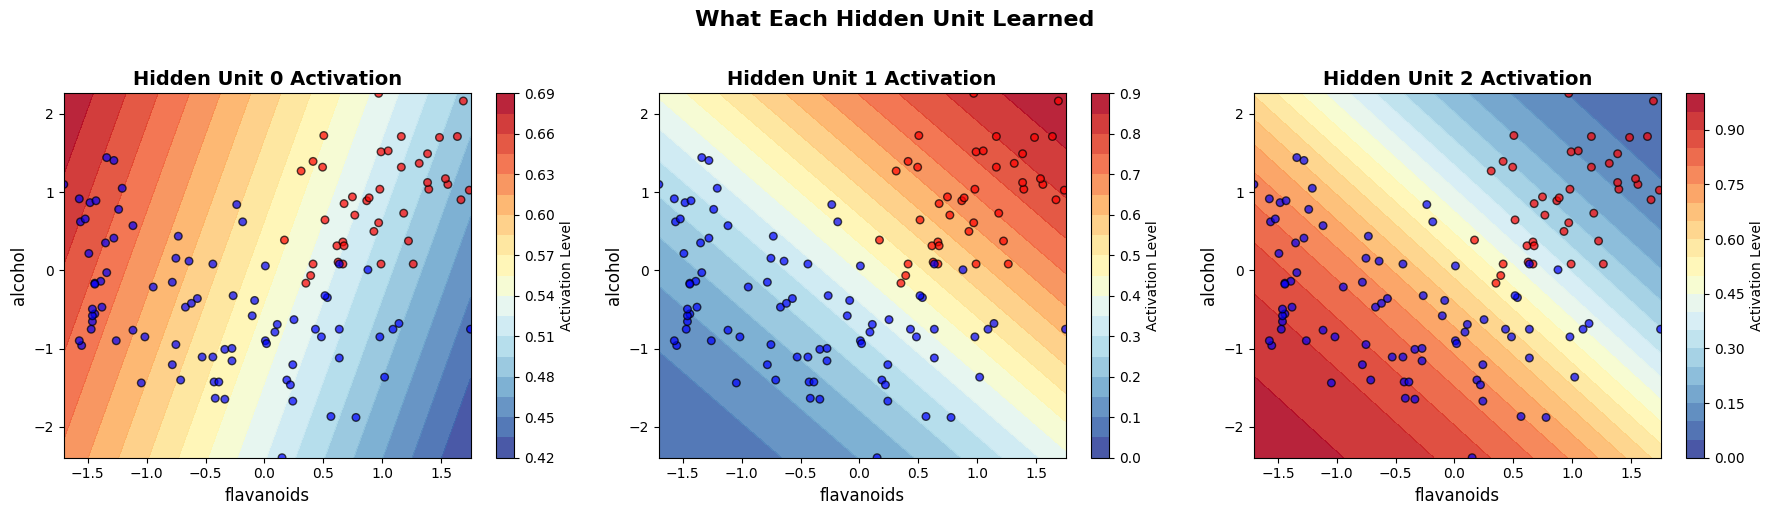

Each hidden unit specializes in detecting different patterns:
- Darker blue = low activation (unit is 'off')
- Darker red = high activation (unit is 'on')


In [86]:
# Calculate hidden layer activations for each unit
hidden_activations = tf.sigmoid(X_grid @ W1 + b1).numpy()

# Plot each hidden unit's activation pattern
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for unit in range(3):
    Z = hidden_activations[:, unit].reshape(100, 100)
    
    # Plot contour
    im = axes[unit].contourf(X1_grid, X2_grid, Z, levels=20, cmap='RdYlBu_r', alpha=0.9)
    
    # Overlay training data
    axes[unit].scatter(Xt_train[:, feat_idx1], Xt_train[:, feat_idx2], 
                       c=Y_train.ravel(), cmap='bwr', edgecolor='black', 
                       alpha=0.7, s=30, marker='o')
    
    axes[unit].set_title(f'Hidden Unit {unit} Activation', fontsize=14, fontweight='bold')
    axes[unit].set_xlabel(data.feature_names[feat_idx1], fontsize=12)
    axes[unit].set_ylabel(data.feature_names[feat_idx2], fontsize=12)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axes[unit])
    cbar.set_label('Activation Level', fontsize=10)

plt.suptitle('What Each Hidden Unit Learned', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Each hidden unit specializes in detecting different patterns:")
print("- Darker blue = low activation (unit is 'off')")
print("- Darker red = high activation (unit is 'on')")

### Output Layer Visualization (3D)
The output layer combines the 3 hidden units to make the final decision.

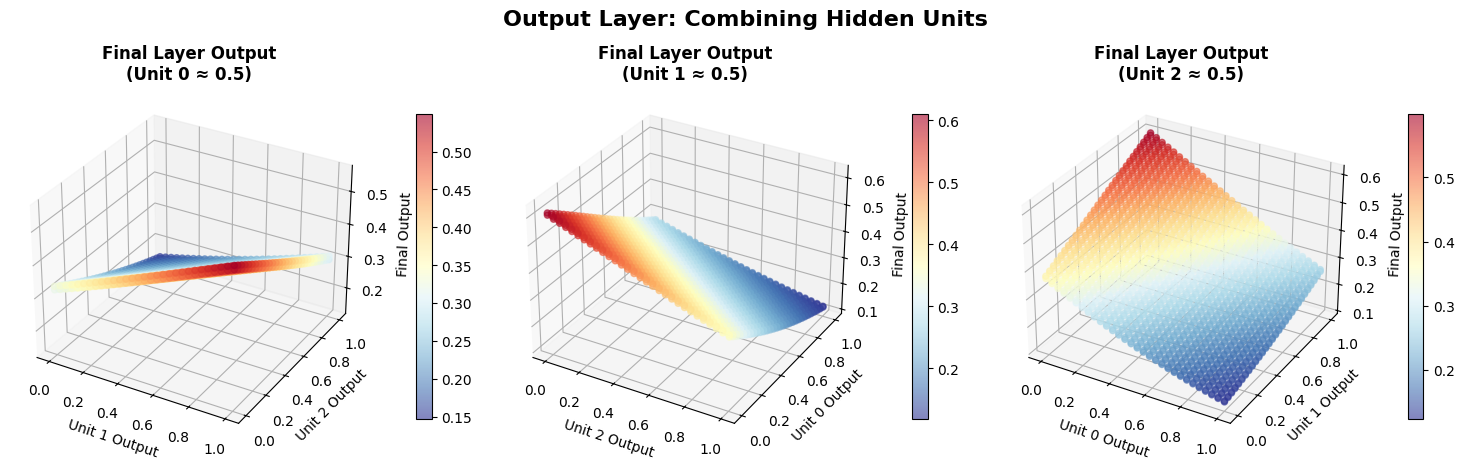

In [87]:
from mpl_toolkits.mplot3d import Axes3D

# Create grid for 3 hidden unit outputs
u0 = np.linspace(0, 1, 30)
u1 = np.linspace(0, 1, 30)
u2 = np.linspace(0, 1, 30)

U0, U1, U2 = np.meshgrid(u0, u1, u2)
hidden_grid = np.c_[U0.ravel(), U1.ravel(), U2.ravel()]

# Calculate final layer output
final_layer_output = tf.sigmoid(hidden_grid @ W2 + b2).numpy().ravel()

# Visualize output layer in 3D (fixing one dimension at a time)
fig = plt.figure(figsize=(15, 5))

for i in range(3):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # Fix one unit at 0.5
    mask = np.abs(hidden_grid[:, i] - 0.5) < 0.05
    
    scatter = ax.scatter(hidden_grid[mask, (i+1)%3], 
                        hidden_grid[mask, (i+2)%3],
                        final_layer_output[mask],
                        c=final_layer_output[mask], 
                        cmap='RdYlBu_r', alpha=0.6, s=20)
    
    ax.set_xlabel(f'Unit {(i+1)%3} Output', fontsize=10)
    ax.set_ylabel(f'Unit {(i+2)%3} Output', fontsize=10)
    ax.set_zlabel('Final Output', fontsize=10)
    ax.set_title(f'Final Layer Output\n(Unit {i} ≈ 0.5)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)

plt.suptitle('Output Layer: Combining Hidden Units', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Complete Network Visualization
Left: Raw output (probability). Right: Final decision after threshold (0.5)

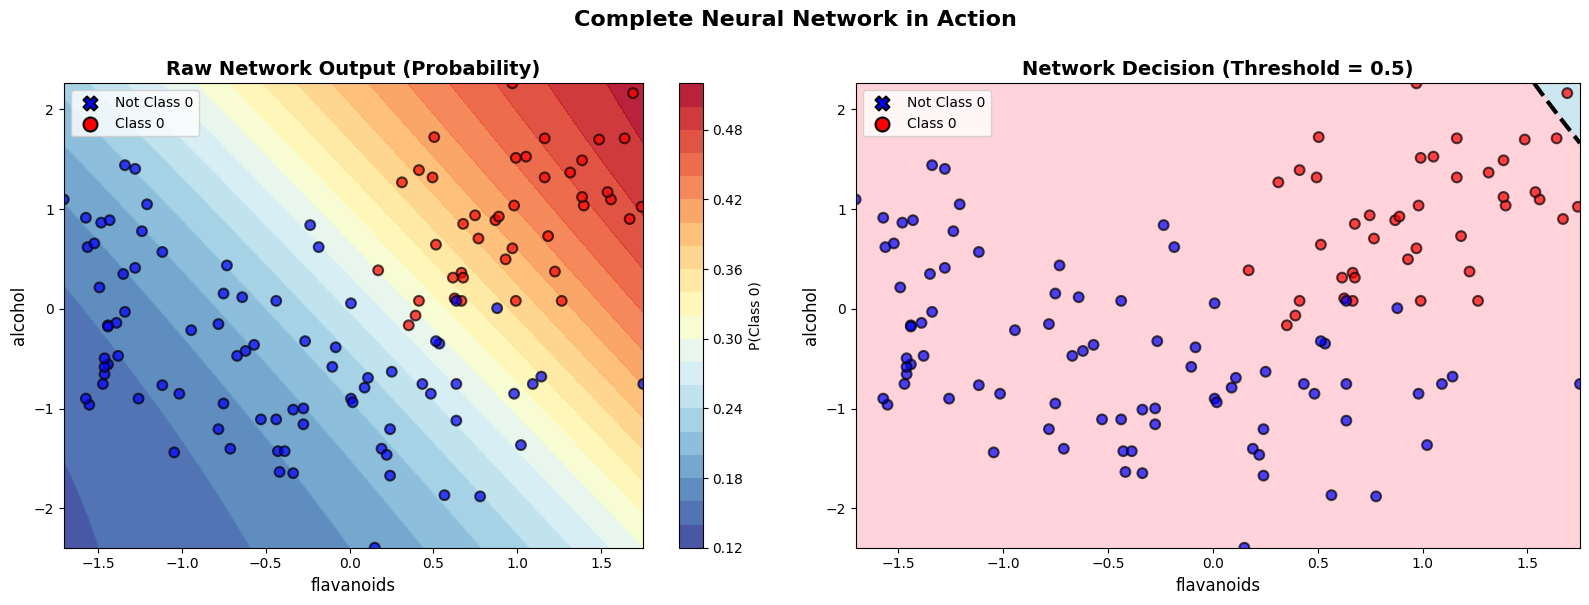


Network successfully learned to classify Class 0 vs Others!
Training accuracy: 96.77%
Test accuracy: 88.89%


In [88]:
# Get model predictions on the grid
final_output = model.predict(X_grid, verbose=0).reshape(100, 100)

# Apply decision threshold
final_decision = (final_output > 0.5).astype(int)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Raw output (probabilities)
im1 = axes[0].contourf(X1_grid, X2_grid, final_output, levels=20, cmap='RdYlBu_r', alpha=0.9)
axes[0].scatter(Xt_train[:, feat_idx1], Xt_train[:, feat_idx2], 
                c=Y_train.ravel(), cmap='bwr', edgecolor='black', 
                s=50, alpha=0.7, linewidth=1.5)
axes[0].set_title('Raw Network Output (Probability)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(data.feature_names[feat_idx1], fontsize=12)
axes[0].set_ylabel(data.feature_names[feat_idx2], fontsize=12)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('P(Class 0)', fontsize=10)

# Add markers for training data
for i, (marker, label) in enumerate([('X', 'Not Class 0'), ('o', 'Class 0')]):
    mask = Y_train.ravel() == i
    axes[0].scatter([], [], c=['blue', 'red'][i], marker=marker, 
                    s=100, edgecolor='black', linewidth=1.5, label=label)
axes[0].legend(loc='best', fontsize=10)

# RIGHT: Decision boundary (after threshold)
im2 = axes[1].contourf(X1_grid, X2_grid, final_decision, levels=1, 
                       colors=['#FFB6C1', '#ADD8E6'], alpha=0.6)
axes[1].scatter(Xt_train[:, feat_idx1], Xt_train[:, feat_idx2], 
                c=Y_train.ravel(), cmap='bwr', edgecolor='black', 
                s=50, alpha=0.7, linewidth=1.5)
axes[1].set_title('Network Decision (Threshold = 0.5)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(data.feature_names[feat_idx1], fontsize=12)
axes[1].set_ylabel(data.feature_names[feat_idx2], fontsize=12)

# Add decision boundary line
contour = axes[1].contour(X1_grid, X2_grid, final_output, levels=[0.5], 
                          colors='black', linewidths=3, linestyles='--')
axes[1].clabel(contour, inline=True, fontsize=10, fmt='Decision Boundary')

# Add markers for training data
for i, (marker, label) in enumerate([('X', 'Not Class 0'), ('o', 'Class 0')]):
    mask = Y_train.ravel() == i
    axes[1].scatter([], [], c=['blue', 'red'][i], marker=marker, 
                    s=100, edgecolor='black', linewidth=1.5, label=label)
axes[1].legend(loc='best', fontsize=10)

plt.suptitle('Complete Neural Network in Action', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\nNetwork successfully learned to classify Class 0 vs Others!")
print(f"Training accuracy: {accuracy_score(Y_train, (model.predict(Xt_train, verbose=0) > 0.5).astype(int))*100:.2f}%")
print(f"Test accuracy: {accuracy*100:.2f}%")

### Bonus: Confusion Matrix & Feature Importance

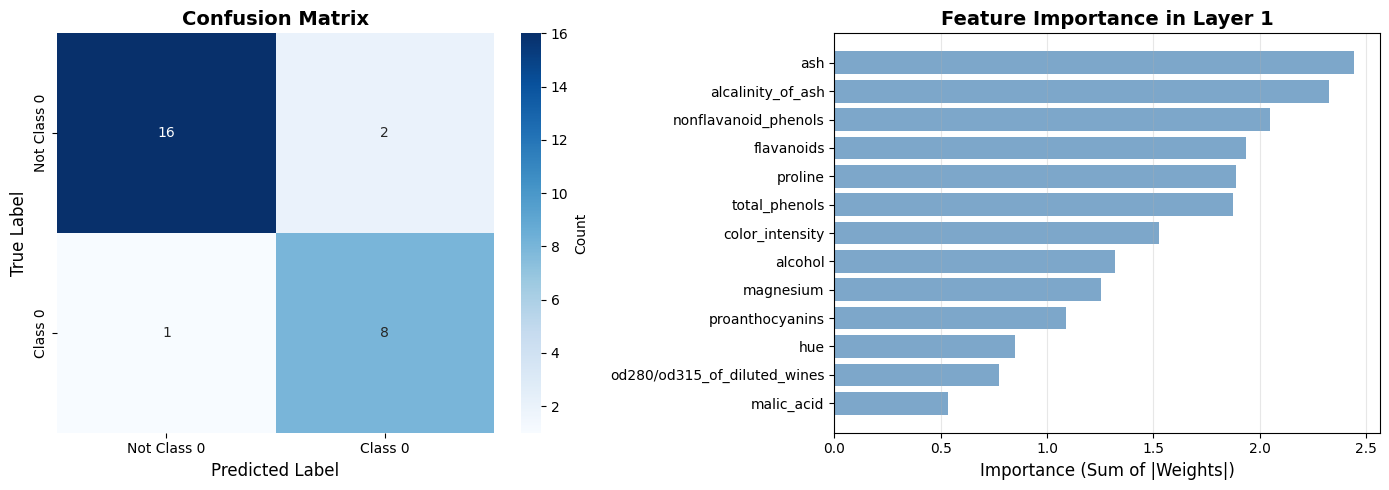


Top 3 most important features:
1. ash: 2.444
2. alcalinity_of_ash: 2.326
3. nonflavanoid_phenols: 2.049


In [89]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Not Class 0', 'Class 0'])
axes[0].set_yticklabels(['Not Class 0', 'Class 0'])

# Feature Importance (sum of absolute weights from layer 1)
feature_importance = np.abs(W1).sum(axis=1)
feature_names_sorted = [data.feature_names[i] for i in np.argsort(feature_importance)]
importance_sorted = np.sort(feature_importance)

axes[1].barh(feature_names_sorted, importance_sorted, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Importance (Sum of |Weights|)', fontsize=12)
axes[1].set_title('Feature Importance in Layer 1', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 3 most important features:")
top_indices = np.argsort(feature_importance)[-3:][::-1]
for i, idx in enumerate(top_indices, 1):
    print(f"{i}. {data.feature_names[idx]}: {feature_importance[idx]:.3f}")